In [7]:
#!/usr/bin/env python
# coding: utf-8

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut


In [8]:
# Load target labels
target_path = os.path.join("final", "targets.csv")
target = pd.read_csv(target_path, index_col=0)

# Compute majority class baseline
majority_class = target["best_algorithm"].value_counts().idxmax()
majority_count = target["best_algorithm"].value_counts().max()
total = len(target)
majority_accuracy = majority_count / total

print(f"📊 Majority Class: {majority_class}")
print(f"📉 Majority Class Accuracy (baseline): {majority_accuracy:.2%}")


📊 Majority Class: Support Vector Machine
📉 Majority Class Accuracy (baseline): 53.70%


In [9]:
d2v = pd.read_csv("qualities/d2v/test_combined_metafeatures.csv",index_col=0)
traditional = pd.read_csv("qualities/traditional/225_qualities_processed.csv",index_col=0)
hybrid = pd.concat([traditional, d2v], axis=1, join='inner')
y = pd.read_csv("final/targets.csv",index_col=0)

In [11]:
output_dir = "final"
os.makedirs(output_dir, exist_ok=True)

# === Add target column ===
target_column = y["best_algorithm_encoded"]

d2v_with_y = d2v.join(target_column, how="inner")
traditional_with_y = traditional.join(target_column, how="inner")
hybrid_with_y = hybrid.join(target_column, how="inner")

d2v_with_y.to_csv(os.path.join(output_dir, "d2v_with_target.csv"))
traditional_with_y.to_csv(os.path.join(output_dir, "traditional_with_target.csv"))
hybrid_with_y.to_csv(os.path.join(output_dir, "hybrid_with_target.csv"))

print("All files saved to:", output_dir)


All files saved to: final


In [13]:
# Load labeled meta-features
d2v = pd.read_csv("final/d2v_with_target.csv", index_col=0)
traditional = pd.read_csv("final/traditional_with_target.csv", index_col=0)
hybrid = pd.read_csv("final/hybrid_with_target.csv", index_col=0)

print("Meta-feature datasets loaded.")
print("Shapes:")
print("  - d2v:", d2v.shape)
print("  - traditional:", traditional.shape)
print("  - hybrid:", hybrid.shape)

Meta-feature datasets loaded.
Shapes:
  - d2v: (54, 33)
  - traditional: (54, 94)
  - hybrid: (54, 126)


In [14]:
def evaluate_dataset(df, seed):
    X, y = df.iloc[:, :-1].values, df.iloc[:, -1].values
    loo = LeaveOneOut()
    clf = RandomForestClassifier(random_state=seed)

    correct = 0
    for train_index, test_index in loo.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        correct += int(y_pred[0] == y_test[0])

    return correct / len(X)


In [15]:
# Evaluation
N_REPEATS = 10
SEED = 175
datasets = {
    "d2v": d2v,
    "traditional": traditional,
    "hybrid": hybrid
}
results = {}

for name in sorted(datasets):
    print(f"\n🎯 Evaluating {name} meta-model ...")
    scores = []
    for rep in range(N_REPEATS):
        seed = SEED + rep
        acc = evaluate_dataset(datasets[name], seed)
        scores.append(acc)
    results[name] = scores
    print(f"  ✅ Mean accuracy: {np.mean(scores):.4f} ± {np.std(scores):.4f}")


🎯 Evaluating d2v meta-model ...
  ✅ Mean accuracy: 0.5796 ± 0.0263

🎯 Evaluating hybrid meta-model ...
  ✅ Mean accuracy: 0.6574 ± 0.0344

🎯 Evaluating traditional meta-model ...
  ✅ Mean accuracy: 0.6630 ± 0.0259


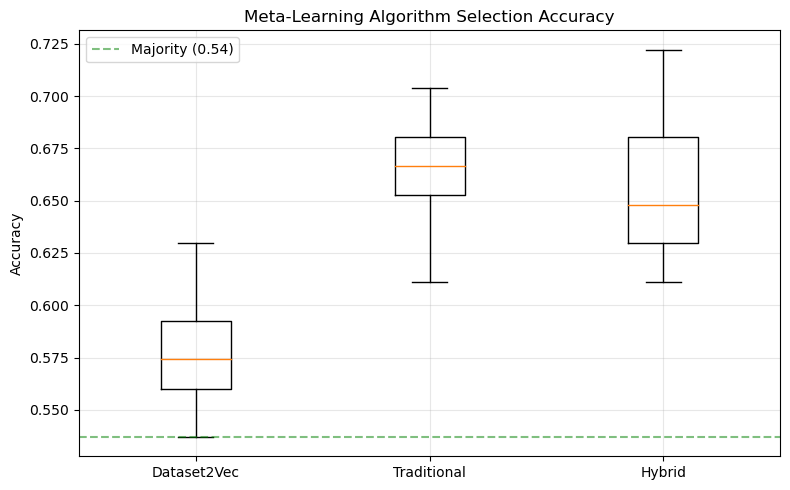

In [16]:
# Plot results
plt.figure(figsize=(8, 5))
plt.boxplot([results["d2v"], results["traditional"], results["hybrid"]],
            labels=["Dataset2Vec", "Traditional", "Hybrid"])

plt.axhline(majority_accuracy, color="green", linestyle="--", alpha=0.5,
            label=f"Majority ({majority_accuracy:.2f})")

plt.title("Meta-Learning Algorithm Selection Accuracy")
plt.ylabel("Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()